In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style('whitegrid')

## Load Dataset

In [46]:
df = pd.read_csv('../backend/dataset/interactions_dataset.csv')
df.head()

,_id,user_id,car_id,action,timestamp
0,69ac7a10828eb233d9c323a2,69aaefb2915fbb114154328e,69ac7a10828eb233d9c323a1,search,2026-03-07T19:18:40.405Z
1,69ac7e88e84d1d3bf0b34f1a,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc706,click,2026-03-07T19:37:44.138Z
2,69ac7e88e84d1d3bf0b34f1b,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc706,view,2026-03-07T19:37:44.211Z
3,69ac7f53614c638059001e06,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc70c,click,2026-03-07T19:41:07.755Z
4,69ac7f53614c638059001e07,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc70c,view,2026-03-07T19:41:07.828Z


## Dataset Information

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   _id        73 non-null     object
 1   user_id    73 non-null     object
 2   car_id     73 non-null     object
 3   action     73 non-null     object
 4   timestamp  73 non-null     object
dtypes: object(5)
memory usage: 3.0+ KB


In [48]:
df.isnull().sum()

_id          0
user_id      0
car_id       0
action       0
timestamp    0
dtype: int64

In [49]:
df['action'].value_counts()

action
view      30
click     24
book      18
search     1
Name: count, dtype: int64

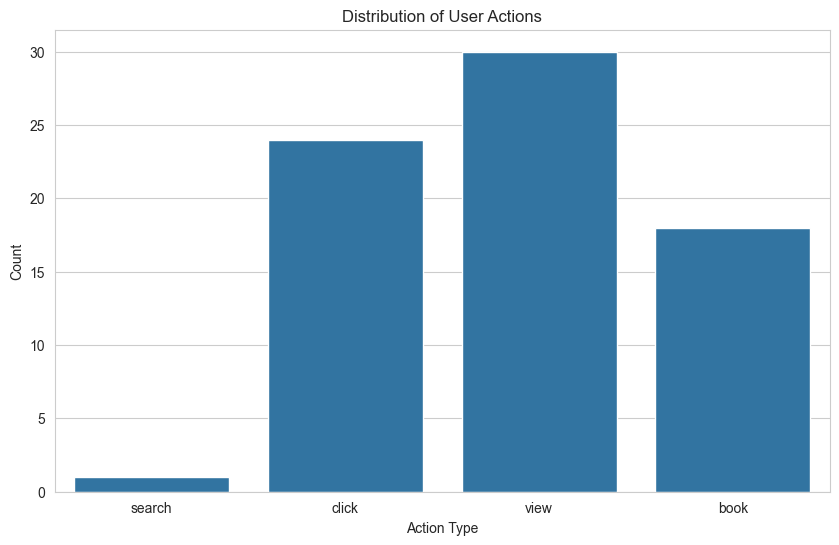

In [50]:
sns.countplot(data=df, x='action')
plt.title('Distribution of User Actions')
plt.xlabel('Action Type')
plt.ylabel('Count')
plt.show()

In [51]:
top_cars = df['car_id'].value_counts().head(10)
top_cars

car_id
69ac788e1c95fc99606cc706    23
69ac788e1c95fc99606cc721    22
69ac788e1c95fc99606cc705    11
69ac788e1c95fc99606cc709     6
69ac788e1c95fc99606cc70b     4
69ac788e1c95fc99606cc70a     2
69ac788e1c95fc99606cc70c     2
69ac788e1c95fc99606cc71c     2
69ac7a10828eb233d9c323a1     1
Name: count, dtype: int64

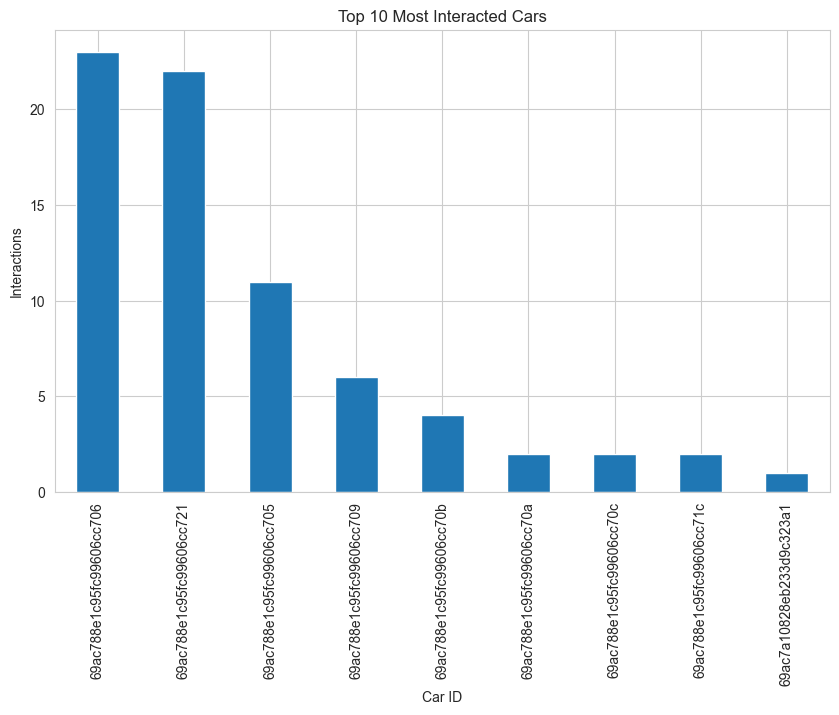

In [52]:
top_cars.plot(kind='bar')
plt.title('Top 10 Most Interacted Cars')
plt.xlabel('Car ID')
plt.ylabel('Interactions')
plt.show()

In [53]:
top_users = df['user_id'].value_counts().head(10)
top_users

user_id
69aaefb2915fbb114154328e    31
69ad129876eb7d2afa12d6d2    30
69ad165bc6eb45c9fdeef5ba    12
Name: count, dtype: int64

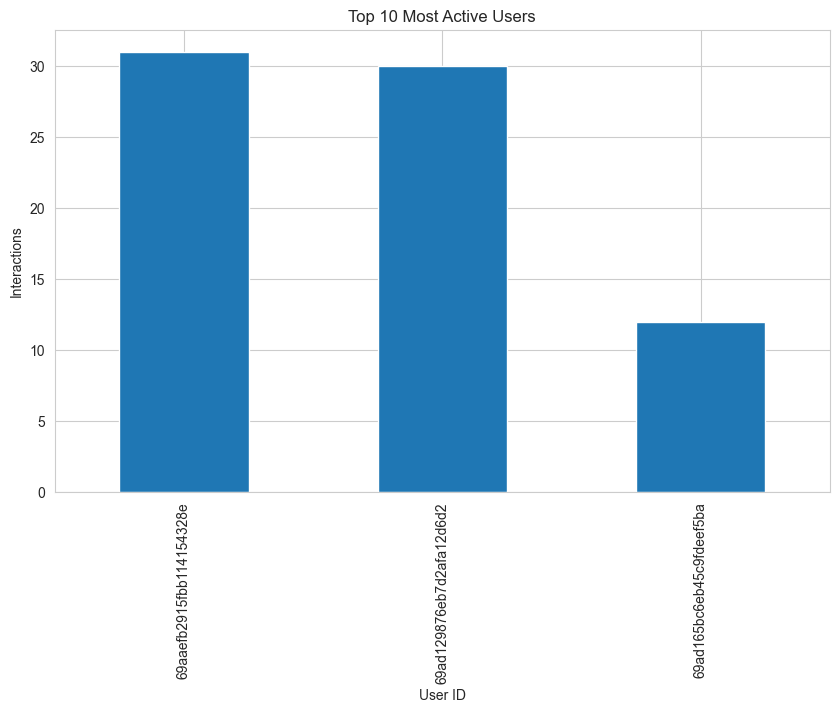

In [54]:
top_users.plot(kind='bar')
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Interactions')
plt.show()

In [55]:
weights = {
    'click':1,
    'view':2,
    'book':5
}

df['interaction_score'] = df['action'].map(weights)
df.head()

,_id,user_id,car_id,action,timestamp,interaction_score
0,69ac7a10828eb233d9c323a2,69aaefb2915fbb114154328e,69ac7a10828eb233d9c323a1,search,2026-03-07T19:18:40.405Z,NaN
1,69ac7e88e84d1d3bf0b34f1a,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc706,click,2026-03-07T19:37:44.138Z,1.0
2,69ac7e88e84d1d3bf0b34f1b,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc706,view,2026-03-07T19:37:44.211Z,2.0
3,69ac7f53614c638059001e06,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc70c,click,2026-03-07T19:41:07.755Z,1.0
4,69ac7f53614c638059001e07,69aaefb2915fbb114154328e,69ac788e1c95fc99606cc70c,view,2026-03-07T19:41:07.828Z,2.0


In [56]:
user_car_matrix = df.pivot_table(
    index='user_id',
    columns='car_id',
    values='interaction_score',
    aggfunc='sum',
    fill_value=0
)

user_car_matrix.head()

car_id,69ac788e1c95fc99606cc705,69ac788e1c95fc99606cc706,69ac788e1c95fc99606cc709,69ac788e1c95fc99606cc70a,69ac788e1c95fc99606cc70b,69ac788e1c95fc99606cc70c,69ac788e1c95fc99606cc71c,69ac788e1c95fc99606cc721,69ac7a10828eb233d9c323a1
user_id,,,,,,,,,
69aaefb2915fbb114154328e,20.0,8.0,0.0,3.0,6.0,3.0,0.0,29.0,0.0
69ad129876eb7d2afa12d6d2,13.0,26.0,6.0,0.0,0.0,0.0,3.0,25.0,0.0
69ad165bc6eb45c9fdeef5ba,0.0,29.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


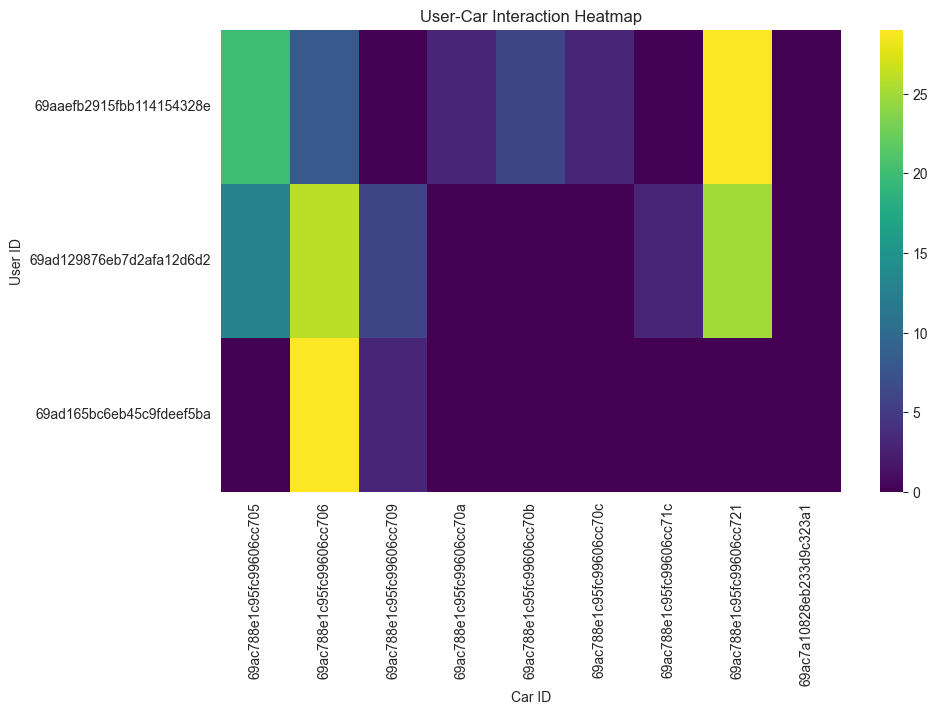

In [57]:
plt.figure()
sns.heatmap(user_car_matrix, cmap='viridis')
plt.title('User-Car Interaction Heatmap')
plt.xlabel('Car ID')
plt.ylabel('User ID')
plt.show()